### 1. 사용 내역 데이터 전처리

### 1.1 데이터 로딩 및 1차 전처리

In [2]:
import os
import glob
import pandas as pd
import numpy as np

In [2]:
USAGE_DIR = "raw_data/usage"
REPAIR_DIR = "raw_data/repair"

usage_files = sorted(glob.glob(os.path.join(USAGE_DIR, "*.csv")))
repair_files = sorted(glob.glob(os.path.join(REPAIR_DIR, "*.csv")))

print("usage 파일 수:", len(usage_files))
print("repair 파일 수:", len(repair_files))

usage 파일 수: 59
repair 파일 수: 12


In [ ]:
# 누락 컬럼 확인
keep_cols = ["자전거번호", "대여일시", "반납일시", "이용시간", "이용거리"]

for file in usage_files:
    df = pd.read_csv(file, encoding="cp949", low_memory=False, nrows=5)
    missing_cols = [col for col in keep_cols if col not in df.columns]
    
    if missing_cols:
        print("파일:", os.path.basename(file))
        print("누락 컬럼:", missing_cols)
        print("실제 컬럼:", df.columns.tolist())
        print("-" * 80)

In [3]:
# usage에서 남길 컬럼
keep_cols = ["자전거번호", "대여일시", "반납일시", "이용시간", "이용거리"]

summary_list = []

for i, file in enumerate(usage_files):
    print(f"[{i+1}/{len(usage_files)}] 처리 중:", os.path.basename(file))

    df = pd.read_csv(file, encoding="cp949", low_memory=False)

    # 컬럼명 통일
    df = df.rename(columns={
    "이용시간(분)": "이용시간",
    "이용거리(M)": "이용거리",
    })
    
    df_cut = df[keep_cols].copy()

    # 데이터 타입 정리
    df_cut["자전거번호"] = df_cut["자전거번호"].astype(str).str.strip()
    df_cut["대여일시"] = pd.to_datetime(df_cut["대여일시"], errors="coerce")
    df_cut["반납일시"] = pd.to_datetime(df_cut["반납일시"], errors="coerce")
    df_cut["이용시간"] = pd.to_numeric(df_cut["이용시간"], errors="coerce")
    df_cut["이용거리"] = pd.to_numeric(df_cut["이용거리"], errors="coerce")

    # 핵심 컬럼 결측치 제거
    df_cut = df_cut.dropna(subset=["자전거번호", "대여일시", "반납일시"])

    # 날짜, 시간 컬럼 생성
    df_cut["date"] = df_cut["대여일시"].dt.date
    df_cut["hour"] = df_cut["대여일시"].dt.hour

    # 일별 요약
    summary = (
        df_cut.groupby(["자전거번호", "date", "hour"], as_index=False)
        .agg(
            시간별_총이용시간=("이용시간", "sum"), # 사용량 확인
            시간별_총이용거리=("이용거리", "sum"), # 사용량 확인
            시간별_이용횟수=("자전거번호", "size"), # 사용 빈도 확인
            # 첫_대여시각=("대여일시", "min"),
            # 마지막_반납시각=("반납일시", "max")
        )
    )

    # 전처리 된 각 데이터 합치기
    summary_list.append(summary)

[1/59] 처리 중: 2102.csv
[2/59] 처리 중: 2103.csv
[3/59] 처리 중: 2104.csv
[4/59] 처리 중: 2105.csv
[5/59] 처리 중: 2106.csv
[6/59] 처리 중: 2107.csv
[7/59] 처리 중: 2108.csv
[8/59] 처리 중: 2109.csv
[9/59] 처리 중: 2110.csv
[10/59] 처리 중: 2111.csv
[11/59] 처리 중: 2112.csv
[12/59] 처리 중: 2201.csv
[13/59] 처리 중: 2202.csv
[14/59] 처리 중: 2203.csv
[15/59] 처리 중: 2204.csv
[16/59] 처리 중: 2205.csv
[17/59] 처리 중: 2206.csv
[18/59] 처리 중: 2207.csv
[19/59] 처리 중: 2208.csv
[20/59] 처리 중: 2209.csv
[21/59] 처리 중: 2210.csv
[22/59] 처리 중: 2211.csv
[23/59] 처리 중: 2212.csv
[24/59] 처리 중: 2301.csv
[25/59] 처리 중: 2302.csv
[26/59] 처리 중: 2303.csv
[27/59] 처리 중: 2304.csv
[28/59] 처리 중: 2305.csv
[29/59] 처리 중: 2306.csv
[30/59] 처리 중: 2307.csv
[31/59] 처리 중: 2308.csv
[32/59] 처리 중: 2309.csv
[33/59] 처리 중: 2310.csv
[34/59] 처리 중: 2311.csv
[35/59] 처리 중: 2312.csv
[36/59] 처리 중: 2401.csv
[37/59] 처리 중: 2402.csv
[38/59] 처리 중: 2403.csv
[39/59] 처리 중: 2404.csv
[40/59] 처리 중: 2405.csv
[41/59] 처리 중: 2406.csv
[42/59] 처리 중: 2407.csv
[43/59] 처리 중: 2408.csv
[44/59] 처리 중: 2409.c

In [4]:
# 전체 코드 합치기
usage_all = pd.concat(summary_list, ignore_index=True)

display(usage_all)
print("전체 shape:", usage_all.shape)

,자전거번호,date,hour,시간별_총이용시간,시간별_총이용거리,시간별_이용횟수
0,SPB-00385,2021-02-01,11,3.0,560.00,1
1,SPB-00385,2021-02-01,16,14.0,2320.00,1
2,SPB-00385,2021-02-01,17,7.0,2000.00,1
3,SPB-00385,2021-02-01,23,5.0,1230.00,1
4,SPB-00385,2021-02-02,6,7.0,1380.00,1
...,...,...,...,...,...,...
158381692,SPB-85099,2025-12-24,7,13.0,1679.56,1
158381693,SPB-85099,2025-12-31,13,5.0,600.35,1
158381694,SPB-85100,2025-12-17,11,25.0,3784.31,1
158381695,SPB-85100,2025-12-18,13,4.0,724.63,1


전체 shape: (158381697, 6)


In [5]:
# 결측치 확인
usage_all.isna().sum()

자전거번호        0
date         0
hour         0
시간별_총이용시간    0
시간별_총이용거리    0
시간별_이용횟수     0
dtype: int64

In [6]:
%pip install pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
# usage_all의 date 컬럼 타입 수정
usage_all = usage_all.copy()

usage_all["date"] = pd.to_datetime(usage_all["date"], errors="coerce")
usage_all["hour"] = pd.to_numeric(usage_all["hour"], errors="coerce")
usage_all["시간별_총이용시간"] = pd.to_numeric(usage_all["시간별_총이용시간"], errors="coerce")
usage_all["시간별_총이용거리"] = pd.to_numeric(usage_all["시간별_총이용거리"], errors="coerce")
usage_all["시간별_이용횟수"] = pd.to_numeric(usage_all["시간별_이용횟수"], errors="coerce")

usage_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158381697 entries, 0 to 158381696
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   자전거번호      object        
 1   date       datetime64[ns]
 2   hour       int32         
 3   시간별_총이용시간  float64       
 4   시간별_총이용거리  float64       
 5   시간별_이용횟수   int64         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(1)
memory usage: 6.5+ GB


In [11]:
# 사용내역 전처리 데이터 저장
usage_all.to_parquet("processed_data/usage_all.parquet", index=False)

### 1.2 사용내역 데이터 eda 처리

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
import pandas as pd

# Mac에서 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

# 그림 기본 설정
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

# 열려 있던 figure 정리
plt.close("all")

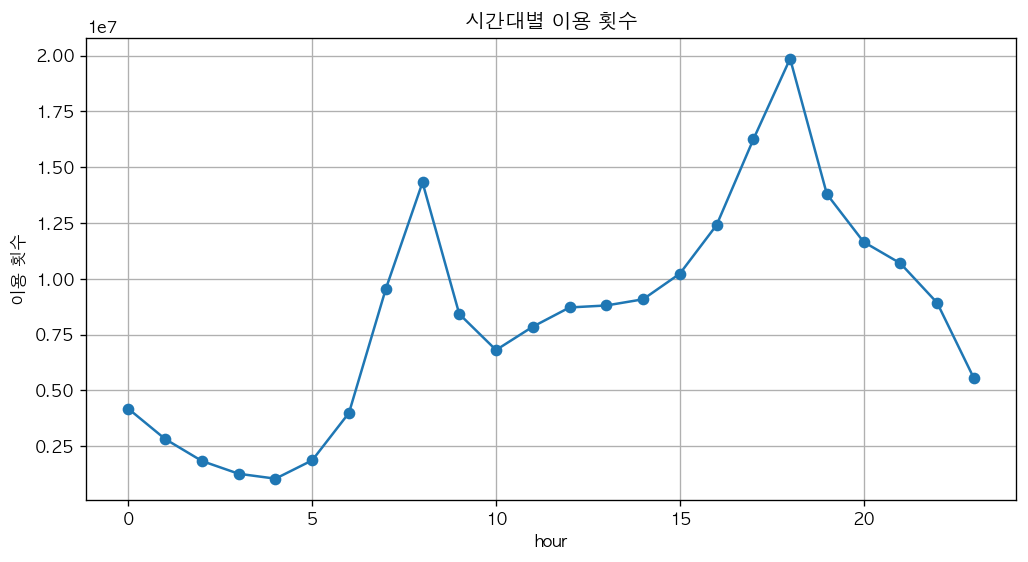

In [9]:
# 시간대별 이용 횟수
hour_usage = usage_all.groupby("hour")["시간별_이용횟수"].sum().sort_index()

fig, ax = plt.subplots()
ax.plot(hour_usage.index, hour_usage.values, marker="o")
ax.set_title("시간대별 이용 횟수")
ax.set_xlabel("hour")
ax.set_ylabel("이용 횟수")
ax.grid(True)

display(fig)
plt.close(fig)

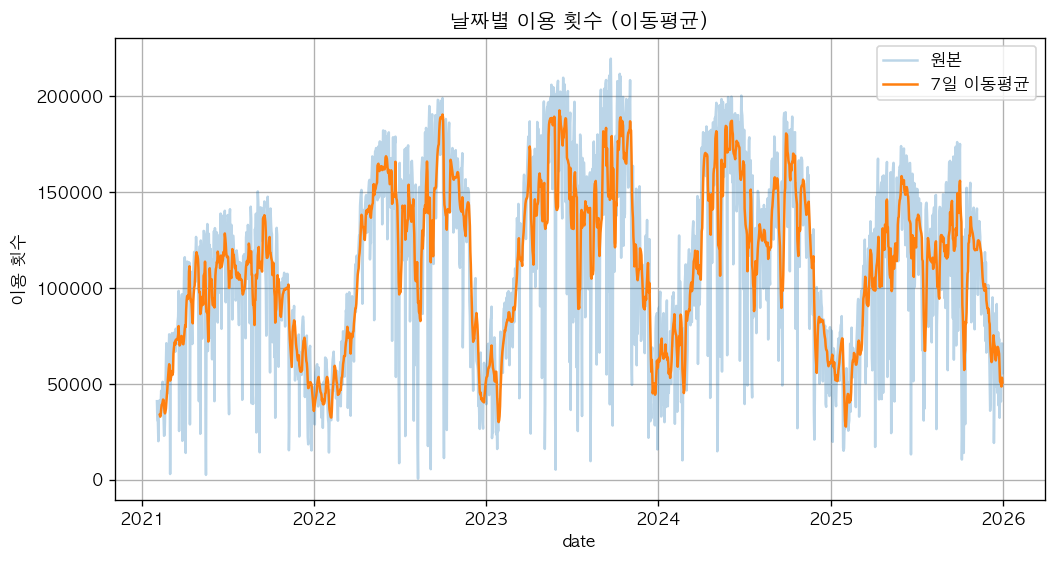

In [10]:
# 날짜별 평균 이용횟수
daily_usage = usage_all.groupby("date")["시간별_이용횟수"].sum().sort_index()

daily_usage_ma = daily_usage.rolling(window=7).mean()

fig, ax = plt.subplots()
ax.plot(daily_usage.index, daily_usage.values, alpha=0.3, label="원본")
ax.plot(daily_usage_ma.index, daily_usage_ma.values, label="7일 이동평균")

ax.set_title("날짜별 이용 횟수 (이동평균)")
ax.set_xlabel("date")
ax.set_ylabel("이용 횟수")
ax.legend()
ax.grid(True)

display(fig)
plt.close(fig)

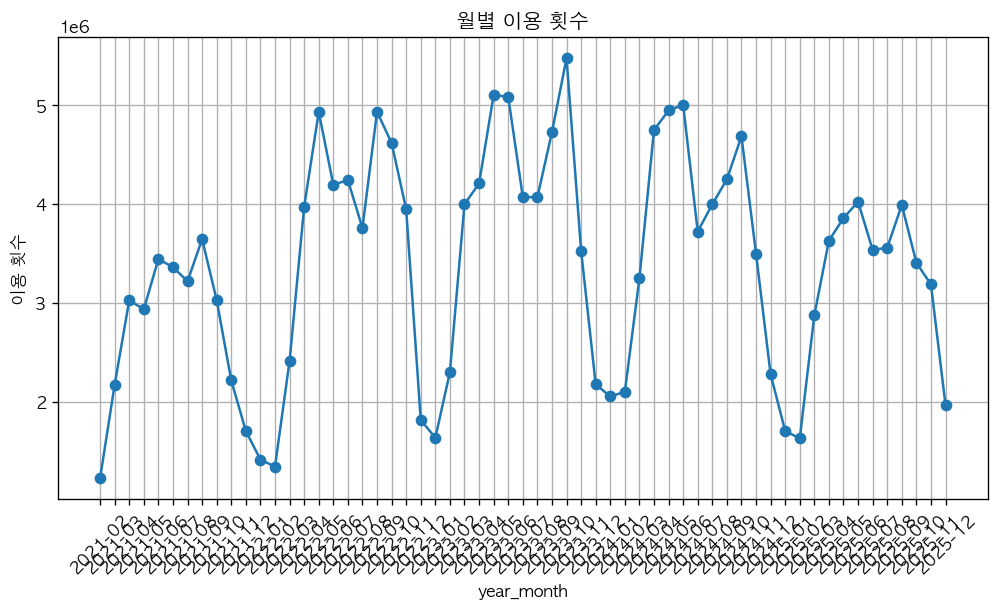

In [11]:
# 월별 이용 횟수
usage_all["year_month"] = usage_all["date"].dt.to_period("M")

monthly_usage = usage_all.groupby("year_month")["시간별_이용횟수"].sum()

fig, ax = plt.subplots()
ax.plot(monthly_usage.index.astype(str), monthly_usage.values, marker="o")

ax.set_title("월별 이용 횟수")
ax.set_xlabel("year_month")
ax.set_ylabel("이용 횟수")
ax.tick_params(axis='x', rotation=45)
ax.grid(True)

display(fig)
plt.close(fig)

### 2. 고장 내역 데이터 전처리

### 2.1 데이터 로딩 및 1차 전처리

In [12]:
# repair 데이터 샘플 확인
repair_sample = pd.read_csv(repair_files[0], encoding="cp949", low_memory=False) if repair_files else pd.DataFrame()
print(repair_sample.shape)
print(repair_sample.columns.tolist())
repair_sample.head()

(1408, 3)
['자전거번호', '등록일시', '고장구분']


,자전거번호,등록일시,고장구분
0,SPB-41936,2021-01-01 00:44:00,기타
1,SPB-42181,2021-01-01 02:42:00,타이어
2,SPB-36237,2021-01-01 03:53:00,기타
3,SPB-33399,2021-01-01 04:56:00,체인
4,SPB-36328,2021-01-01 08:21:00,기타


In [ ]:
# 2101 데이터 파일 필터링
target_file = [f for f in repair_files if "2011_2101.csv" in f][0]

print("처리 파일:", target_file)

# 데이터 로드
df = pd.read_csv(target_file, encoding="cp949", low_memory=False)

# datetime 변환
df['등록일시'] = pd.to_datetime(df['등록일시'], errors='coerce')

# 2021년만 필터링
df_2021 = df[df['등록일시'].dt.year == 2021]

# 저장
save_path = os.path.join(REPAIR_DIR, "2101.csv")
df_2021.to_csv(save_path, index=False, encoding="cp949")

print("저장 완료:", save_path)
print("행 개수:", df_2021.shape)

In [14]:
repair_files = sorted(glob.glob(os.path.join(REPAIR_DIR, "*.csv")))
repair_files

['raw_data/repair/2101.csv',
 'raw_data/repair/2102_2106.csv',
 'raw_data/repair/2107_2112.csv',
 'raw_data/repair/2201_2206.csv',
 'raw_data/repair/2207_2212.csv',
 'raw_data/repair/2301_2306.csv',
 'raw_data/repair/2307_2310.csv',
 'raw_data/repair/2311_2312.csv',
 'raw_data/repair/2401_2406.csv',
 'raw_data/repair/2407_2412.csv',
 'raw_data/repair/2501_2506.csv',
 'raw_data/repair/2507_2512.csv']

In [15]:
# 각 데이터 파일별로 컬럼명 확인
# 인코딩 언어 확인
for file in repair_files:
    try:
        df_temp = pd.read_csv(file, encoding='cp949', nrows=3)
    except:
        try:
            df_temp = pd.read_csv(file, encoding='utf-8', nrows=3)
        except:
            df_temp = pd.read_excel(file, nrows=3)

    df_temp.columns = df_temp.columns.str.strip()
    print(f"\n파일명: {file}")
    print(df_temp.columns.tolist())


파일명: raw_data/repair/2101.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2102_2106.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2107_2112.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2201_2206.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2207_2212.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2301_2306.csv
['자전거번호', '등록일시', '구분']

파일명: raw_data/repair/2307_2310.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2311_2312.csv
['자전거번호', '등록일시', '고장구분']

파일명: raw_data/repair/2401_2406.csv
['자전거번호', '등록일시', '구분']

파일명: raw_data/repair/2407_2412.csv
['자전거번호', '등록일시', '구분']

파일명: raw_data/repair/2501_2506.csv
['자전거번호', '등록일시', '구분']

파일명: raw_data/repair/2507_2512.csv
['자전거번호', '등록일시', '구분']


In [16]:
# 컬럼 통일하고 데이터 concat
repair_dfs = []

for file in repair_files:
    print(f"처리 중: {os.path.basename(file)}")
    
    try:
        df = pd.read_csv(file, encoding="cp949", low_memory=False)
    except:
        df = pd.read_csv(file, encoding="utf-8", low_memory=False)

    # 컬럼명 공백 제거
    df.columns = df.columns.str.strip()

    # 컬럼명 통일
    if '구분' in df.columns and '고장구분' not in df.columns:
        df = df.rename(columns={'구분': '고장구분'})

    # 필요한 컬럼만 남기기
    df = df[['자전거번호', '등록일시', '고장구분']].copy()

    # 등록일시 문자열 정리
    df['등록일시'] = df['등록일시'].astype(str).str.strip()
    df['등록일시'] = (
        df['등록일시']
        .str.replace('.', '-', regex=False)
        .str.replace('/', '-', regex=False)
    )
    df['등록일시'] = df['등록일시'].replace(['', 'nan', 'None'], pd.NA)

    # mixed 포맷 datetime 변환
    df['등록일시'] = pd.to_datetime(
        df['등록일시'],
        format='mixed',
        errors='coerce'
    )

    # 변환 실패 확인
    na_count = df['등록일시'].isna().sum()
    # print(f"등록일시 결측치: {na_count}")

    repair_dfs.append(df)

repair_all = pd.concat(repair_dfs, ignore_index=True)

print("최종 shape:", repair_all.shape)
print("최종 결측 수:", repair_all['등록일시'].isna().sum())
display(repair_all)

처리 중: 2101.csv
처리 중: 2102_2106.csv
처리 중: 2107_2112.csv
처리 중: 2201_2206.csv
처리 중: 2207_2212.csv
처리 중: 2301_2306.csv
처리 중: 2307_2310.csv
처리 중: 2311_2312.csv
처리 중: 2401_2406.csv
처리 중: 2407_2412.csv
처리 중: 2501_2506.csv
처리 중: 2507_2512.csv
최종 shape: (779052, 3)
최종 결측 수: 0


,자전거번호,등록일시,고장구분
0,SPB-41936,2021-01-01 00:44:00,기타
1,SPB-42181,2021-01-01 02:42:00,타이어
2,SPB-36237,2021-01-01 03:53:00,기타
3,SPB-33399,2021-01-01 04:56:00,체인
4,SPB-36328,2021-01-01 08:21:00,기타
...,...,...,...
779047,SPB-68754,2025-12-31 23:12:55,체인
779048,SPB-62680,2025-12-31 23:32:06,기타
779049,SPB-34168,2025-12-31 23:33:45,체인
779050,SPB-34168,2025-12-31 23:33:45,기타


In [17]:
repair_all.to_parquet("processed_data/repair_all.parquet", index=False)
repair_all.to_csv("processed_data/repair_all.csv", encoding='cp949', index=False)

In [18]:
# EDA용 데이터
repair_all_2 = repair_all.copy()

# date + hour 생성 -> usage와 컬럼 통일
repair_all_2['date'] = repair_all_2['등록일시'].dt.floor('D')
repair_all_2['hour'] = repair_all_2['등록일시'].dt.hour

# 정렬
repair_all_2 = repair_all_2.sort_values(
    ['date', 'hour']
).reset_index(drop=True)

repair_all_2 = repair_all_2.drop(columns=['등록일시'])
repair_all_2 = repair_all_2[
    ['자전거번호', 'date', 'hour', '고장구분']
]

display(repair_all_2)

,자전거번호,date,hour,고장구분
0,SPB-41936,2021-01-01,0,기타
1,SPB-42181,2021-01-01,2,타이어
2,SPB-36237,2021-01-01,3,기타
3,SPB-33399,2021-01-01,4,체인
4,SPB-36328,2021-01-01,8,기타
...,...,...,...,...
779047,SPB-68754,2025-12-31,23,체인
779048,SPB-62680,2025-12-31,23,기타
779049,SPB-34168,2025-12-31,23,체인
779050,SPB-34168,2025-12-31,23,기타


In [19]:
# 저장
repair_all_2.to_csv(
    "processed_data/repair_all_2.csv",
    encoding='cp949',
    index=False
)

repair_all_2.to_parquet(
    "processed_data/repair_all_2.parquet",
    index=False
)

### 2.2 고장 데이터 eda 처리

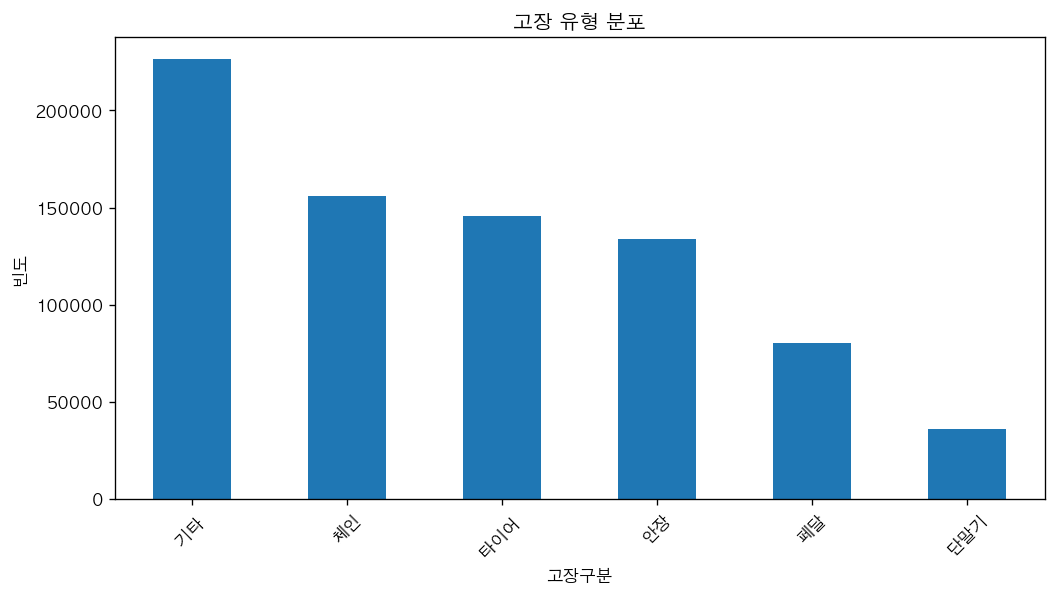

In [20]:
# 고장 분포 확인
repair_all_2['고장구분'].value_counts().plot(kind='bar')
plt.title('고장 유형 분포')
plt.xlabel('고장구분')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.show()

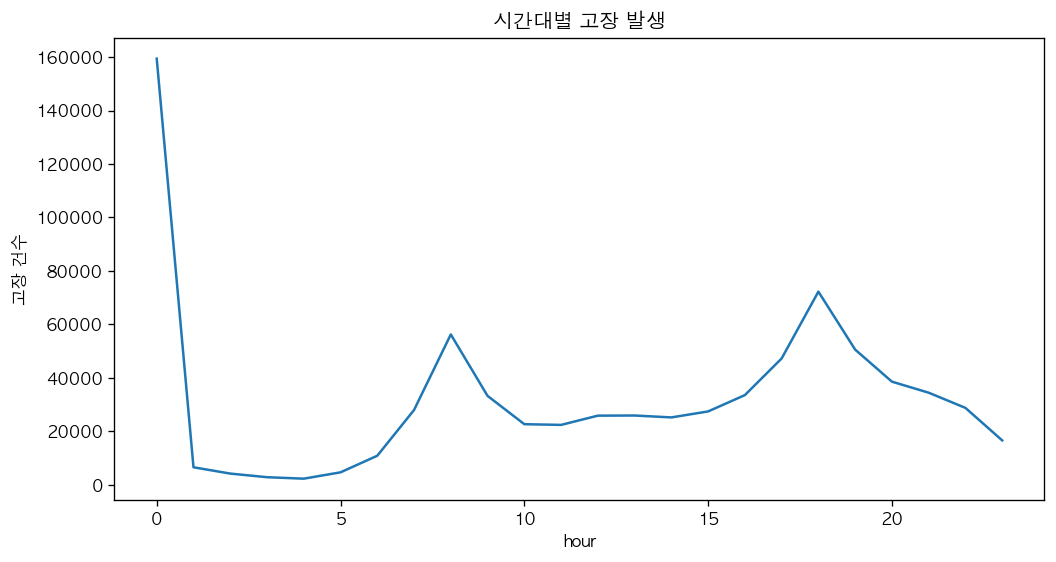

In [21]:
# 시간대별 고장 분포 확인
repair_all_2.groupby('hour').size().plot(kind='line')
plt.title('시간대별 고장 발생')
plt.xlabel('hour')
plt.ylabel('고장 건수')
plt.show()

# 시간이 없는 데이터가 많아서 00시의 고장 발생 분포가 많은 것 같음

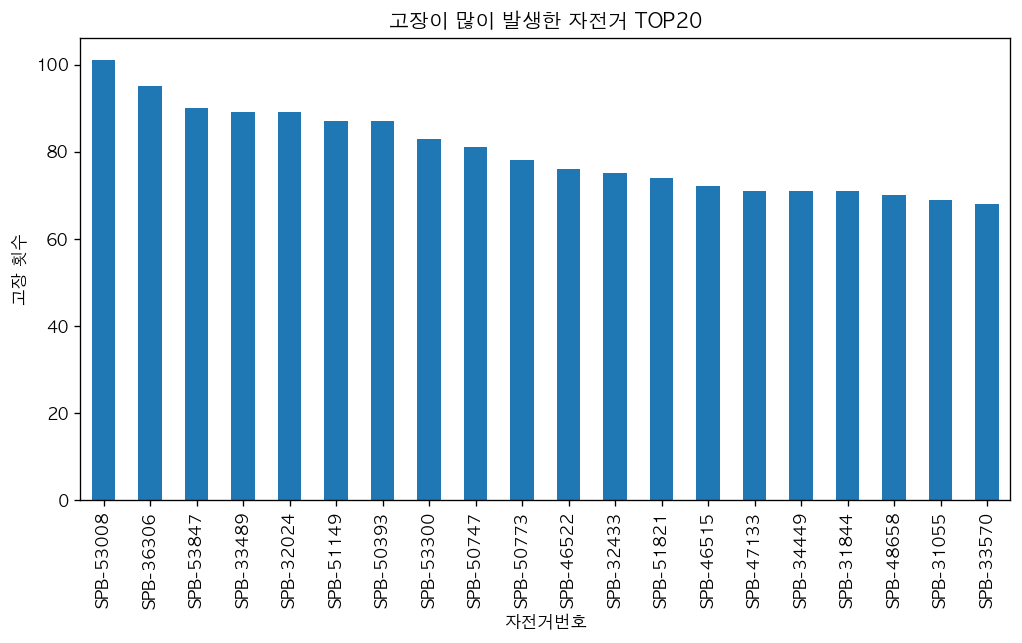

In [22]:
# 자전거별 고장 빈도 확인
top_bikes = repair_all_2['자전거번호'].value_counts().head(20)

top_bikes.plot(kind='bar')
plt.title('고장이 많이 발생한 자전거 TOP20')
plt.xlabel('자전거번호')
plt.ylabel('고장 횟수')
plt.xticks(rotation=90)
plt.show()

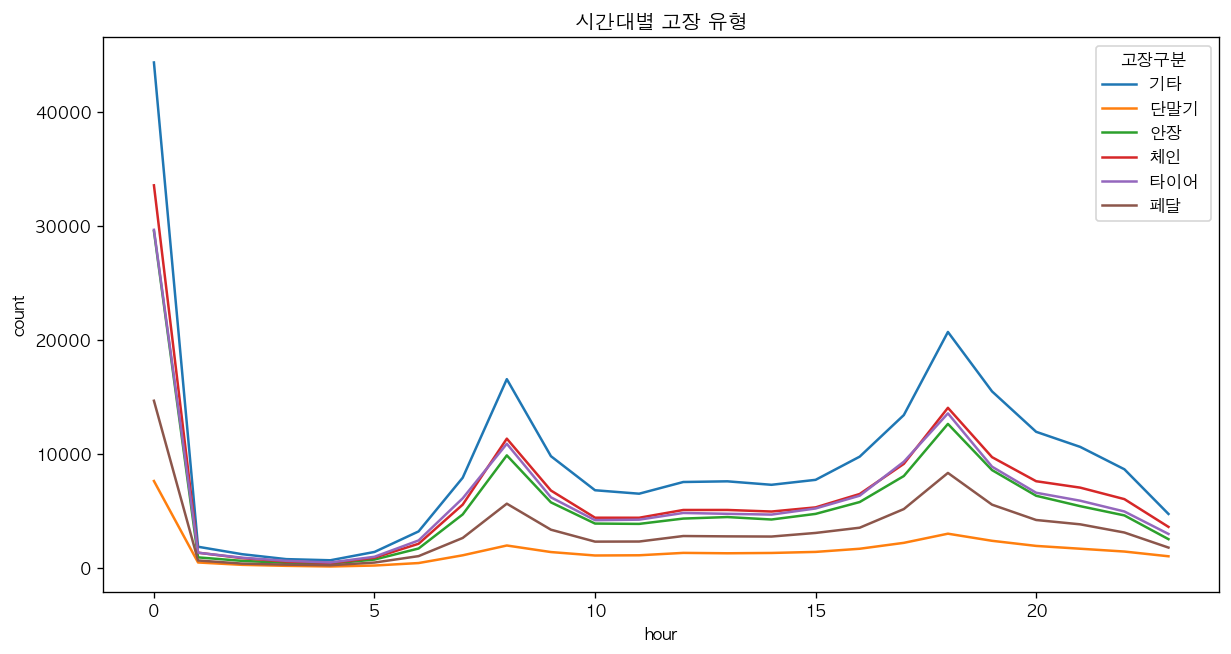

In [23]:
# 시간대별 고장 유형 확인
pivot = repair_all_2.pivot_table(
    index='hour',
    columns='고장구분',
    aggfunc='size',
    fill_value=0
)

pivot.plot(figsize=(12,6))
plt.title('시간대별 고장 유형')
plt.xlabel('hour')
plt.ylabel('count')
plt.show()

### 3. id 기준으로 합친 데이터 eda (코랩으로 진행)

In [ ]:
merged_data = pd.read_parquet("/processed_data/merged_data.parquet")

print(merged_data.shape)
display(merged_data.head())

In [ ]:
merged_data_repair = pd.read_parquet("/processed_data/merged_data_repair.parquet")

print(merged_data_repair.shape)
display(merged_data_repair.head())

In [ ]:
# 고장 유형별 빈도

# 고장구분목록 파싱
all_types = merged_data_repair['고장구분목록'].str.split(',').explode().str.strip()
all_types = all_types[all_types != '']

type_counts = all_types.value_counts()
print("고장 유형 수:", len(type_counts))

type_counts.head(15).plot(kind='barh', figsize=(10,6), title='고장 유형 TOP 15')
plt.xlabel('건수')
plt.tight_layout()
plt.show()

In [ ]:
# 월별 고장 추이
merged_data['month'] = pd.to_datetime(merged_data['date']).dt.to_period('M')

monthly = merged_data.groupby('month').agg(
    총이용건수=('시간별_이용횟수', 'sum'),
    고장건수=('고장발생', 'sum')
).reset_index()
monthly['고장률'] = monthly['고장건수'] / monthly['총이용건수']

fig, ax1 = plt.subplots(figsize=(14,5))
ax1.bar(monthly['month'].astype(str), monthly['총이용건수'], alpha=0.3, label='이용건수')
ax2 = ax1.twinx()
ax2.plot(monthly['month'].astype(str), monthly['고장률'], color='red', marker='o', label='고장률')
ax1.set_xlabel('월')
ax1.set_ylabel('이용건수')
ax2.set_ylabel('고장률')
plt.title('월별 이용건수 & 고장률')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.set_xticks(range(0, len(monthly), 6)) # 6개월 간격
ax1.set_xticklabels(monthly['month'].astype(str).iloc[::6], rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 시간대별 고장 패턴
hourly = merged_data.groupby('hour').agg(
    이용건수=('시간별_이용횟수', 'sum'),
    고장건수=('고장발생', 'sum')
).reset_index()
hourly['고장률'] = hourly['고장건수'] / hourly['이용건수']

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(hourly['hour'], hourly['이용건수'], alpha=0.3, label='이용건수')
ax2 = ax1.twinx()
ax2.plot(hourly['hour'], hourly['고장률'], color='red', marker='o', label='고장률')
ax1.set_xlabel('시간대')
ax1.set_ylabel('이용건수')
ax2.set_ylabel('고장률')
plt.title('시간대별 이용건수 & 고장률')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# 고장 주기 분석
# 자전거별 고장 간 간격(일) 계산

# 고장 발생 행만 추출 (자전거번호, 날짜)
fault_dates = merged_data[merged_data['고장발생'] == 1][['자전거번호', 'date']].copy()
fault_dates['date'] = pd.to_datetime(fault_dates['date'])
fault_dates = fault_dates.sort_values(['자전거번호', 'date'])

fault_dates['prev_fault'] = fault_dates.groupby('자전거번호')['date'].shift(1)
fault_dates['고장간격_일'] = (fault_dates['date'] - fault_dates['prev_fault']).dt.days
fault_dates = fault_dates.dropna(subset=['고장간격_일'])

print("고장 간격 통계 (일):")
print(fault_dates['고장간격_일'].describe())

plt.figure(figsize=(12,5))
fault_dates['고장간격_일'].clip(upper=365).hist(bins=50)
plt.title('자전거별 고장 간격 분포 (일)')
plt.xlabel('고장 간격 (일)')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

In [ ]:
# 자전거별 누적 이용시간/거리 계산
merged_data = merged_data.sort_values(['자전거번호', 'date', 'hour'])
merged_data['누적이용시간'] = merged_data.groupby('자전거번호')['시간별_총이용시간'].cumsum()
merged_data['누적이용거리'] = merged_data.groupby('자전거번호')['시간별_총이용거리'].cumsum()

# 고장 시점의 누적 사용량
fault_usage = merged_data[merged_data['고장발생'] == 1][['누적이용시간', '누적이용거리']]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fault_usage['누적이용시간'].clip(upper=fault_usage['누적이용시간'].quantile(0.95)).hist(bins=50, ax=axes[0])
axes[0].set_title('고장 시점 누적 이용시간 분포')
axes[0].set_xlabel('누적 이용시간 (분)')

fault_usage['누적이용거리'].clip(upper=fault_usage['누적이용거리'].quantile(0.95)).hist(bins=50, ax=axes[1])
axes[1].set_title('고장 시점 누적 이용거리 분포')
axes[1].set_xlabel('누적 이용거리 (M)')
plt.tight_layout()
plt.show()

### 4. 날씨 데이터

### 4.1 날씨 데이터 로딩 및 전처리

In [14]:
weather = pd.read_csv("raw_data/weather.csv", encoding='cp949')

print(weather.shape)
display(weather)

(1826, 19)


,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi),강수 계속시간(hr),10분 최다 강수량(mm),10분 최다강수량 시각(hhmi),1시간 최다강수량(mm),1시간 최다 강수량 시각(hhmi),일강수량(mm),일 최심신적설(cm),일 최심신적설 시각(hhmi),일 최심적설(cm),일 최심적설 시각(hhmi),합계 3시간 신적설(cm)
0,108,서울,2021-01-01,-4.2,-9.8,511.0,1.6,1447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,108,서울,2021-01-02,-5.0,-8.4,805.0,-1.4,1346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,108,서울,2021-01-03,-5.6,-9.1,536.0,-2.0,1238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,108,서울,2021-01-04,-3.5,-8.4,656.0,0.3,1535,2.33,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,0.0
4,108,서울,2021-01-05,-5.5,-9.9,2356.0,-2.1,1,5.42,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,108,서울,2025-12-27,-2.6,-8.3,22.0,0.5,1550,0.33,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1822,108,서울,2025-12-28,3.2,0.0,1.0,6.1,1518,4.42,NaN,NaN,NaN,NaN,0.6,NaN,NaN,NaN,NaN,NaN
1823,108,서울,2025-12-29,4.9,-0.1,2345.0,9.1,1446,2.00,NaN,NaN,NaN,NaN,0.3,NaN,NaN,NaN,NaN,NaN
1824,108,서울,2025-12-30,-0.5,-3.7,802.0,3.8,1446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
weather['일시'] = pd.to_datetime(weather['일시'])
weather = weather[weather['일시'] >= '2021-01-01']
weather.to_csv("raw_data/weather.csv", index=False, encoding='cp949')
print("shape:", weather.shape)
display(weather)

shape: (1826, 19)


,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi),강수 계속시간(hr),10분 최다 강수량(mm),10분 최다강수량 시각(hhmi),1시간 최다강수량(mm),1시간 최다 강수량 시각(hhmi),일강수량(mm),일 최심신적설(cm),일 최심신적설 시각(hhmi),일 최심적설(cm),일 최심적설 시각(hhmi),합계 3시간 신적설(cm)
0,108,서울,2021-01-01,-4.2,-9.8,511.0,1.6,1447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,108,서울,2021-01-02,-5.0,-8.4,805.0,-1.4,1346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,108,서울,2021-01-03,-5.6,-9.1,536.0,-2.0,1238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,108,서울,2021-01-04,-3.5,-8.4,656.0,0.3,1535,2.33,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,0.0
4,108,서울,2021-01-05,-5.5,-9.9,2356.0,-2.1,1,5.42,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,108,서울,2025-12-27,-2.6,-8.3,22.0,0.5,1550,0.33,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1822,108,서울,2025-12-28,3.2,0.0,1.0,6.1,1518,4.42,NaN,NaN,NaN,NaN,0.6,NaN,NaN,NaN,NaN,NaN
1823,108,서울,2025-12-29,4.9,-0.1,2345.0,9.1,1446,2.00,NaN,NaN,NaN,NaN,0.3,NaN,NaN,NaN,NaN,NaN
1824,108,서울,2025-12-30,-0.5,-3.7,802.0,3.8,1446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
keep_cols = ['일시', '평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '강수 계속시간(hr)', '일강수량(mm)']
weather = weather[keep_cols]
print(weather.shape)
display(weather)

(1826, 6)


,일시,평균기온(°C),최저기온(°C),최고기온(°C),강수 계속시간(hr),일강수량(mm)
0,2021-01-01,-4.2,-9.8,1.6,NaN,NaN
1,2021-01-02,-5.0,-8.4,-1.4,NaN,NaN
2,2021-01-03,-5.6,-9.1,-2.0,NaN,NaN
3,2021-01-04,-3.5,-8.4,0.3,2.33,0.0
4,2021-01-05,-5.5,-9.9,-2.1,5.42,0.0
...,...,...,...,...,...,...
1821,2025-12-27,-2.6,-8.3,0.5,0.33,0.0
1822,2025-12-28,3.2,0.0,6.1,4.42,0.6
1823,2025-12-29,4.9,-0.1,9.1,2.00,0.3
1824,2025-12-30,-0.5,-3.7,3.8,NaN,NaN


In [17]:
weather = weather.reset_index(drop=True)
weather.to_csv("processed_data/weather.csv", index=False, encoding='cp949')
display(weather)

,일시,평균기온(°C),최저기온(°C),최고기온(°C),강수 계속시간(hr),일강수량(mm)
0,2021-01-01,-4.2,-9.8,1.6,NaN,NaN
1,2021-01-02,-5.0,-8.4,-1.4,NaN,NaN
2,2021-01-03,-5.6,-9.1,-2.0,NaN,NaN
3,2021-01-04,-3.5,-8.4,0.3,2.33,0.0
4,2021-01-05,-5.5,-9.9,-2.1,5.42,0.0
...,...,...,...,...,...,...
1821,2025-12-27,-2.6,-8.3,0.5,0.33,0.0
1822,2025-12-28,3.2,0.0,6.1,4.42,0.6
1823,2025-12-29,4.9,-0.1,9.1,2.00,0.3
1824,2025-12-30,-0.5,-3.7,3.8,NaN,NaN


In [18]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   일시           1826 non-null   datetime64[ns]
 1   평균기온(°C)     1826 non-null   float64       
 2   최저기온(°C)     1825 non-null   float64       
 3   최고기온(°C)     1826 non-null   float64       
 4   강수 계속시간(hr)  777 non-null    float64       
 5   일강수량(mm)     775 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 85.7 KB


In [21]:
# 강수량 결측치 처리
weather['강수 계속시간(hr)'] = weather['강수 계속시간(hr)'].fillna(0)
weather['일강수량(mm)'] = weather['일강수량(mm)'].fillna(0)
print("결측치 확인:")
print(weather.isnull().sum())
display(weather)

결측치 확인:
일시             0
평균기온(°C)       0
최저기온(°C)       1
최고기온(°C)       0
강수 계속시간(hr)    0
일강수량(mm)       0
dtype: int64


,일시,평균기온(°C),최저기온(°C),최고기온(°C),강수 계속시간(hr),일강수량(mm)
0,2021-01-01,-4.2,-9.8,1.6,0.00,0.0
1,2021-01-02,-5.0,-8.4,-1.4,0.00,0.0
2,2021-01-03,-5.6,-9.1,-2.0,0.00,0.0
3,2021-01-04,-3.5,-8.4,0.3,2.33,0.0
4,2021-01-05,-5.5,-9.9,-2.1,5.42,0.0
...,...,...,...,...,...,...
1821,2025-12-27,-2.6,-8.3,0.5,0.33,0.0
1822,2025-12-28,3.2,0.0,6.1,4.42,0.6
1823,2025-12-29,4.9,-0.1,9.1,2.00,0.3
1824,2025-12-30,-0.5,-3.7,3.8,0.00,0.0


### 4.2 날씨 데이터 eda

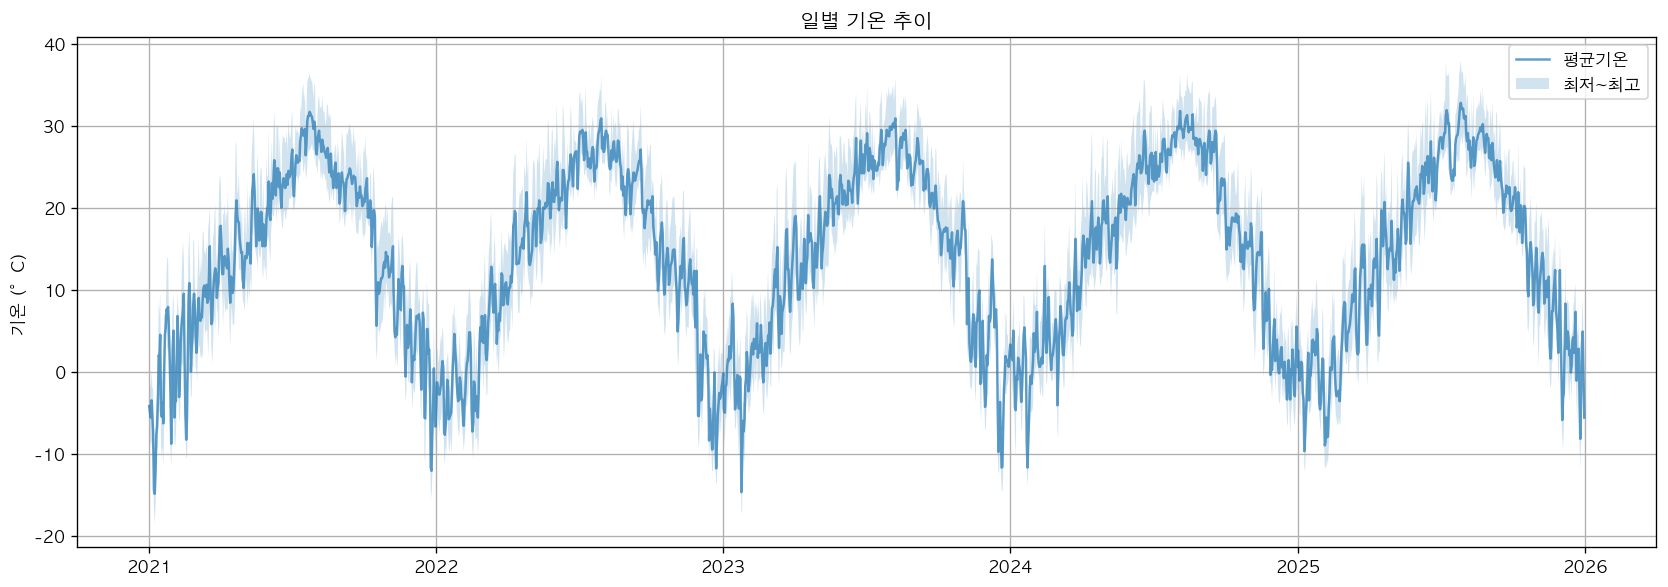

In [ ]:
# 기온 추이 확인
weather['일시'] = pd.to_datetime(weather['일시'])

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(weather['일시'], weather['평균기온(°C)'], alpha=0.7, label='평균기온')
ax.fill_between(weather['일시'], weather['최저기온(°C)'], weather['최고기온(°C)'], alpha=0.2, label='최저~최고')
ax.set_title('일별 기온 추이')
ax.set_ylabel('기온 (°C)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

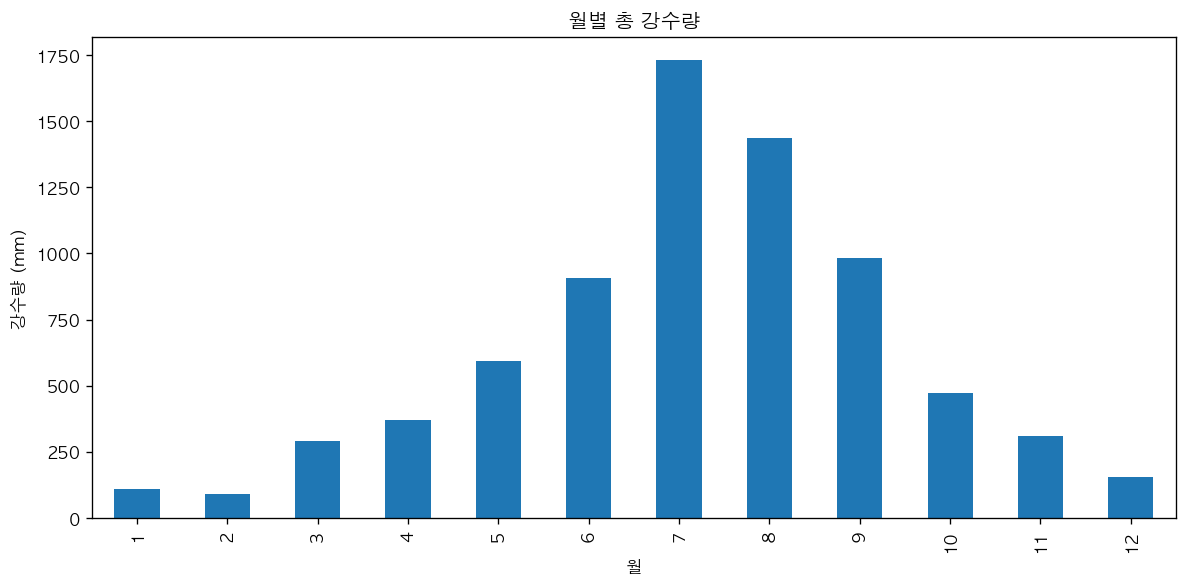

In [23]:
# 월별 강수량 분포
weather['month'] = weather['일시'].dt.month

monthly_rain = weather.groupby('month')['일강수량(mm)'].sum()

fig, ax = plt.subplots()
monthly_rain.plot(kind='bar', ax=ax)
ax.set_title('월별 총 강수량')
ax.set_xlabel('월')
ax.set_ylabel('강수량 (mm)')
plt.tight_layout()
plt.show()

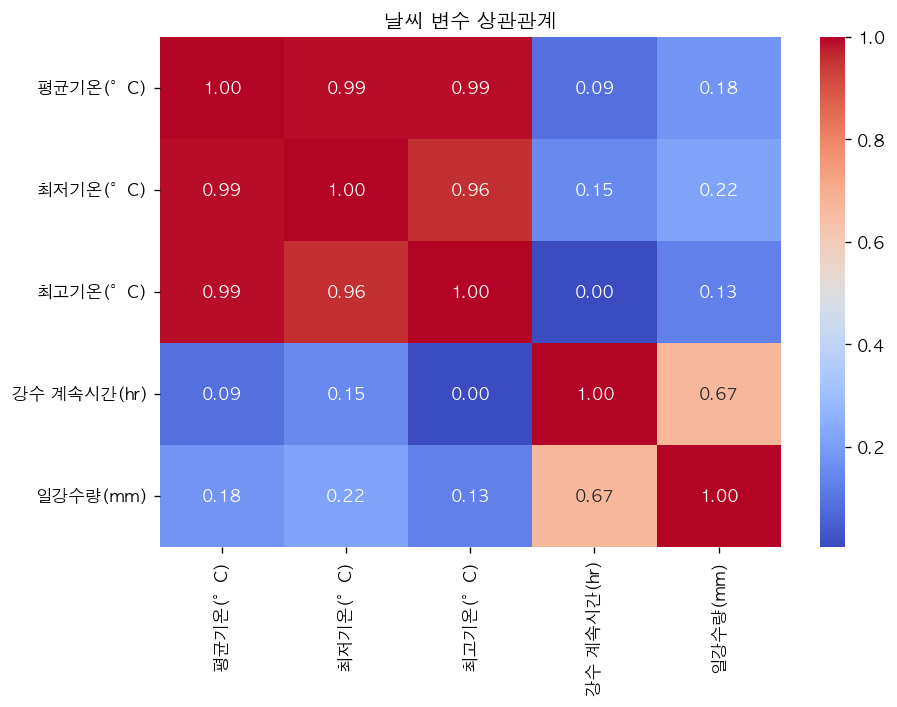

In [ ]:
# 변수 간 상관관계 히트맵
corr = weather[['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '강수 계속시간(hr)', '일강수량(mm)']].corr()

import seaborn as sns
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('날씨 변수 상관관계')
plt.tight_layout()
plt.show()